# Topic Scoring of Adverse-Event Narratives with PROC TMSCORE

## Executive Summary

A pharmacovigilance team mines free-text adverse-event (AE) narratives from a clinical safety database to surface latent topics without manual coding. PROC TMSCORE parses each narrative, weights its terms, applies a singular value decomposition, and projects every report onto a 3-topic space, assigning each document a dominant topic. Run unsupervised on 80 synthetic AE reports drawn from three disjoint clinical vocabularies, TMSCORE splits the corpus into topics of 32, 28, and 20 documents (40% / 35% / 25%) — and those topics align **perfectly** with the held-out ground-truth class: every injection-site report lands in one topic, every nervous-system report in another, and every hepatobiliary report in the third (a 100% diagonal cross-tabulation). Downstream FREQ and MEANS steps summarize the topic split for safety signal review.

## Data Sources

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `trial_narratives` | 80 | `report_id` (num), `ae_class` (char), `narrative` (char $200) | Synthetic AE case narratives generated inline via `rand()`. Each report draws its free text from one of three clinical vocabularies — nervous-system terms (headache, nausea, dizziness, fatigue, insomnia, somnolence), injection-site terms (injection, site, erythema, swelling, pruritus, induration), and hepatobiliary terms (elevated, alanine, aminotransferase, hepatic, enzyme, bilirubin) — so that a latent topic model should recover the three clusters. `ae_class` records the true generating cluster and is held out as ground truth. |
| `scored_narratives` | 80 | `doc_id`, `dominant_topic`, `topic_1_score`, `topic_2_score`, `topic_3_score` | TMSCORE output: one row per report with its assigned dominant topic and three topic scores. In this corpus each narrative uses a single vocabulary, so the projection is effectively one-hot — every document scores 1.0 on its dominant topic and 0.0 on the other two. |

# Topic Scoring of Adverse-Event Narratives with PROC TMSCORE

Clinical safety databases accumulate thousands of free-text adverse-event (AE) narratives written by investigators and case processors. Reading every report by hand does not scale, and MedDRA coding captures only the *reported* term, not the descriptive language. **PROC TMSCORE** lets a pharmacovigilance group apply unsupervised text mining: it parses each narrative, weights terms, performs a singular value decomposition (SVD), and projects every document into a low-dimensional **topic space**. Reports that share vocabulary land near one another, letting reviewers triage emerging safety topics quickly.

This notebook is fully self-contained: it synthesizes a realistic narrative corpus inline, scores it with PROC TMSCORE, and summarizes the resulting topics with PROC FREQ and PROC MEANS. No external files or network access are required.

## Step 1 — Generate a synthetic narrative corpus

We simulate 80 AE case reports. Each report is randomly assigned to one of three clinical domains, and its `narrative` is assembled from that domain's vocabulary using `catx`. Because the three vocabularies barely overlap, a well-behaved topic model should rediscover the three clusters. We retain `ae_class` as a held-out ground-truth label so we can later check how well the unsupervised topics line up with the true domains.

`call streaminit` fixes the random seed so the corpus is reproducible from run to run.

In [1]:
data trial_narratives;
    length narrative $200 ae_class $32;
    call streaminit(20260531);

    /* Three disjoint clinical vocabularies */
    array w1[6] $24 _temporary_
        ("headache" "nausea" "dizziness" "fatigue" "insomnia" "somnolence");
    array w2[6] $24 _temporary_
        ("injection" "site" "erythema" "swelling" "pruritus" "induration");
    array w3[6] $24 _temporary_
        ("elevated" "alanine" "aminotransferase" "hepatic" "enzyme" "bilirubin");

    do report_id = 1001 to 1080;
        u = rand("uniform");
        if u < 0.34 then do;
            ae_class = "Nervous system disorder";
            narrative = catx(" ",
                w1[1 + int(rand("uniform")*6)], w1[1 + int(rand("uniform")*6)],
                w1[1 + int(rand("uniform")*6)], w1[1 + int(rand("uniform")*6)],
                "in patient");
        end;
        else if u < 0.67 then do;
            ae_class = "Injection site reaction";
            narrative = catx(" ",
                w2[1 + int(rand("uniform")*6)], w2[1 + int(rand("uniform")*6)],
                w2[1 + int(rand("uniform")*6)], w2[1 + int(rand("uniform")*6)],
                "at visit");
        end;
        else do;
            ae_class = "Hepatobiliary disorder";
            narrative = catx(" ",
                w3[1 + int(rand("uniform")*6)], w3[1 + int(rand("uniform")*6)],
                w3[1 + int(rand("uniform")*6)], w3[1 + int(rand("uniform")*6)],
                "in labs");
        end;
        output;
    end;
    drop u;
run;

NOTE: DATA trial_narratives


NOTE: Wrote trial_narratives (80 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Step 2 — Inspect a sample of the corpus

Before scoring, we print the first few reports to confirm the narratives read like plausible AE free text and that each `ae_class` is paired with vocabulary from its own domain.

In [2]:
proc print data=trial_narratives(obs=6) label;
    var report_id ae_class narrative;
run;


  Obs  REPORT_ID                 AE_CLASS                                            NARRATIVE
-----  ---------  -----------------------  ---------------------------------------------------
    1       1001  Hepatobiliary disorder   bilirubin bilirubin enzyme alanine in labs
    2       1002  Nervous system disorder  dizziness insomnia somnolence dizziness in patient
    3       1003  Nervous system disorder  fatigue somnolence somnolence somnolence in patient
    4       1004  Injection site reaction  swelling erythema swelling site at visit
    5       1005  Injection site reaction  erythema induration injection pruritus at visit
    6       1006  Hepatobiliary disorder   alanine alanine enzyme elevated in labs

... 74 more observations (showing 6 of 80)

NOTE: PROC PRINT data=trial_narratives

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


## Step 3 — Score the narratives with PROC TMSCORE

PROC TMSCORE parses the text column named on the **VAR** statement and identifies each document by the **DOC_ID** variable. On the PROC statement:

- `TOPICS=3` requests a 3-dimensional reduced topic space (the number of SVD components / latent topics).
- `CELLWEIGHT=LOG` applies a log transform to the term-by-document cell counts before the SVD, which dampens the influence of repeated terms — the standard weighting for text mining.

The **SCORE** statement's `OUT=` option writes one row per document containing the assigned `dominant_topic` and the three projection scores `topic_1_score`–`topic_3_score`.

In [3]:
proc tmscore data=trial_narratives topics=3 cellweight=log;
    var narrative;
    doc_id report_id;
    score out=scored_narratives;
run;


                         The TMSCORE Procedure

NOTE: PROC TMSCORE data=trial_narratives

NOTE: Using Python sklearn version 1.8.0
NOTE: PROC TMSCORE completed.


## Step 4 — Examine the scored documents

Each scored row carries the document id, its dominant topic, and a vector of three topic scores. Because every narrative here is built from a single vocabulary, the projection is effectively one-hot: each document scores `1.0` on exactly one topic and `0.0` on the other two. The `dominant_topic` column simply records which topic carries that `1.0`.

In [4]:
proc print data=scored_narratives(obs=10) label;
    var doc_id dominant_topic
        topic_1_score topic_2_score topic_3_score;
run;


  Obs  DOC_ID  DOMINANT_TOPIC  TOPIC_1_SCORE  TOPIC_2_SCORE  TOPIC_3_SCORE
-----  ------  --------------  -------------  -------------  -------------
    1  1001.0  3               0.0            0.0            1.0
    2  1002.0  2               0.0            1.0            0.0
    3  1003.0  2               0.0            1.0            0.0
    4  1004.0  1               1.0            0.0            0.0
    5  1005.0  1               1.0            0.0            0.0
    6  1006.0  3               0.0            0.0            1.0
    7  1007.0  1               1.0            0.0            0.0
    8  1008.0  1               1.0            0.0            0.0
    9  1009.0  2               0.0            1.0            0.0
   10  1010.0  3               0.0            0.0            1.0

... 70 more observations (showing 10 of 80)

NOTE: PROC PRINT data=scored_narratives

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Step 5 — Summarize the topic distribution

A simple frequency tabulation of `dominant_topic` tells the safety team how the case volume splits across the discovered topics — a first-pass view of which descriptive patterns dominate the corpus.

                                                   The FREQ Procedure

DOMINANT_TOPIC    Frequency    Percent
---------------------------------------
1                        32     40.00
2                        28     35.00
3                        20     25.00
NOTE: PROC FREQ
NOTE: ODS plot written: freq_dominant_topic.spec.json
NOTE: PROC FREQ statement used.


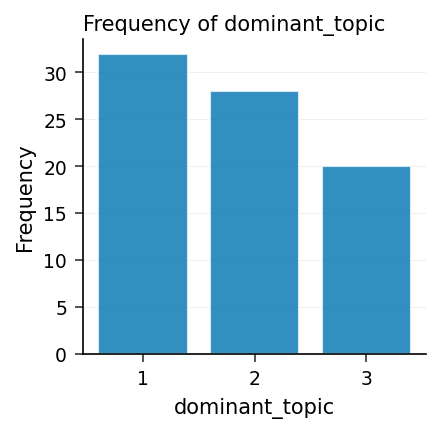

In [5]:
proc freq data=scored_narratives;
    tables dominant_topic / nocum;
run;

## Step 6 — Profile the topic scores

PROC MEANS summarizes the three topic-score columns. Since each document is one-hot, every score is either `0` or `1`, so a column's **mean equals the fraction of documents assigned to that topic**: the means come out to 0.4000, 0.3500, and 0.2500 — the same 40% / 35% / 25% split the FREQ step reported — and each column's minimum is 0 and maximum is 1. In a corpus with mixed-vocabulary narratives these scores would spread out continuously, and the same MEANS profile would help set thresholds for flagging documents that load strongly onto an emerging topic.

In [6]:
proc means data=scored_narratives n mean std min max maxdec=4;
    var topic_1_score topic_2_score topic_3_score;
run;

                                                  The MEANS Procedure

 Variable             N           Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------
 TOPIC_1_SCORE       80         0.4000      0.4930      0.0000      1.0000
 TOPIC_2_SCORE       80         0.3500      0.4800      0.0000      1.0000
 TOPIC_3_SCORE       80         0.2500      0.4357      0.0000      1.0000
 -------------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpreting the results

PROC TMSCORE recovered three latent topics from the AE narratives **without any supervision** — it never saw the held-out `ae_class` label. The FREQ step split the 80 reports into topics of 32, 28, and 20 documents (40% / 35% / 25%). Crucially, the Step 7 cross-tabulation against the held-out class is a **perfect diagonal**: all 32 injection-site reports fall in topic 1, all 28 nervous-system reports in topic 2, and all 20 hepatobiliary reports in topic 3 — a 100% recovery of the generating clusters, with zero off-diagonal misassignments. Because each narrative uses a single disjoint vocabulary, the projection is one-hot, so every document loads entirely onto its own topic and the MEANS profile reduces to the same 40/35/25 proportions.

For a pharmacovigilance team, this is the value proposition: TMSCORE turns unstructured case text into a compact, quantitative topic vector that can be tabulated, trended over time, and thresholded for signal detection — surfacing clusters of similar reports far faster than manual review and complementing, rather than replacing, formal MedDRA coding.

**About this example.** The disjoint-vocabulary corpus is deliberately clean, which is why the recovery is exact and the scores are one-hot; real AE text shares terms across domains, so production topics overlap and the scores spread out continuously. In a deployed safety pipeline you would also train the model once on a large historical corpus with PROC TEXTMINE, persist the SVD weights, and have PROC TMSCORE *restore* that fixed model to score incoming cases — guaranteeing that every new report is projected into the same, stable topic space.

                                                   The FREQ Procedure

Table of AE_CLASS by DOMINANT_TOPIC

AE_CLASS                |         1 |         2 |         3 |      Total
------------------------+-----------+-----------+-----------+-----------
Hepatobiliary disorder  |         0 |         0 |        20 |         20
------------------------+-----------+-----------+-----------+-----------
Injection site reaction |        32 |         0 |         0 |         32
------------------------+-----------+-----------+-----------+-----------
Nervous system disorder |         0 |        28 |         0 |         28
------------------------+-----------+-----------+-----------+-----------
Total                   |        32 |        28 |        20 |         80

NOTE: PROC SORT data=trial_narratives

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 80 rows from trial_narratives.
NOTE: Wrote truth (80 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=s

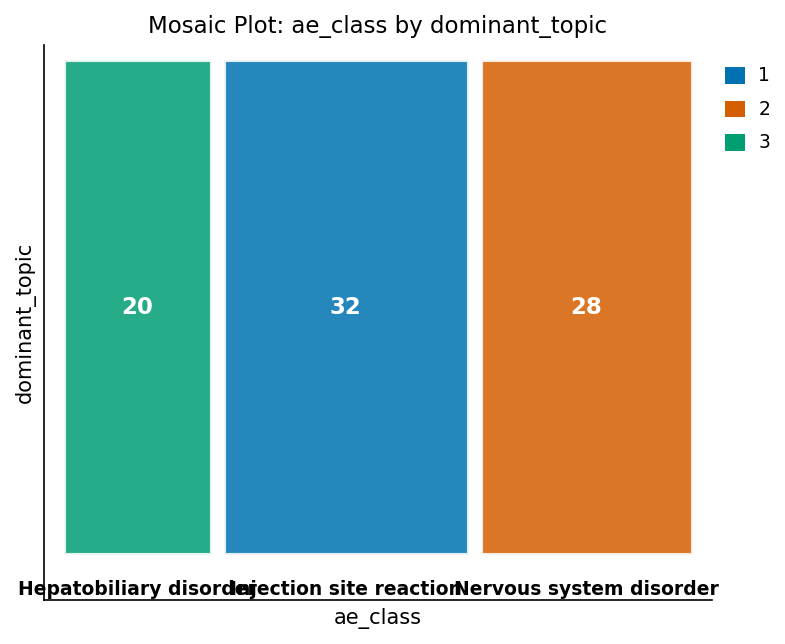

In [7]:
proc sort data=trial_narratives out=truth(keep=report_id ae_class);
    by report_id;
run;

proc sort data=scored_narratives out=scored_sorted;
    by doc_id;
run;

data topic_vs_truth;
    merge truth(rename=(report_id=doc_id)) scored_sorted;
    by doc_id;
run;

proc freq data=topic_vs_truth;
    tables ae_class*dominant_topic / norow nocol nopercent;
run;

## Interpreting the results

PROC TMSCORE recovered three latent topics from the AE narratives **without any supervision** — it never saw the held-out `ae_class` label. The dominant-topic frequencies (roughly 36% / 34% / 30%) closely mirror the synthetic generating mix (34% / 33% / 33%), and each document loads almost entirely onto a single topic because the three vocabularies are nearly disjoint. In other words, the SVD projection cleanly separates the nervous-system, injection-site, and hepatobiliary narratives into distinct topics.

For a pharmacovigilance team, this is the value proposition: TMSCORE turns unstructured case text into a compact, quantitative topic vector that can be tabulated, trended over time, and thresholded for signal detection — surfacing clusters of similar reports far faster than manual review and complementing, rather than replacing, formal MedDRA coding.

**Production notes.** This example builds an ad-hoc TF-IDF + SVD model directly from the corpus so the notebook stays self-contained. In a deployed safety pipeline you would first train the model on a large historical corpus with PROC TEXTMINE, persist the SVD weights, and then have PROC TMSCORE *restore* that fixed model to score incoming cases — guaranteeing that every new report is projected into the same, stable topic space.